In [7]:
import numpy as np
from scipy.integrate import quad, nquad
import matplotlib.pyplot as plt

from scipy.special import erf
from scipy.interpolate import interp1d
from scipy.optimize import brentq, minimize_scalar
from scipy.stats import poisson

#constants
c = 299792 #(km/s)

print("I'm working")

I'm working


In [4]:
#Define the masses, assuming a xenon target
m_dm = 50
m_N  = 122.8 #GeV
A    = 131
m_n  = 0.938 #GeV

mu_dm_N = (m_dm*m_N/(m_dm+m_N)) #reduced mass GeV
mu_dm_n = (m_dm*m_n)/(m_dm+m_n) #GeV
print(mu_dm_N, mu_dm_n)

#convert from nucleon to nucleus cross section
sigma_n = 1e-46 #cm^2
sigma_N = sigma_n*(A**2)*(mu_dm_N/mu_dm_n)**2 #cm^2
print(sigma_N)
#sigma_N *= 2.568e27 #convert to GeV^-2

35.532407407407405 0.9207271585064195
2.55581815058207e-39


### Helm Form Factor Function
https://arxiv.org/pdf/hep-ph/0608035

$$ |F^{SI}(q)|^2 = \big(\frac{(3j_i(qR_1)}{qR_1}\big)^2e^{-q^2s^2} $$

$$ j_1(x) = \frac{sin x}{x^2} - \frac{cos x}{x} $$


In [5]:
def helm_form_factor(E_r, A=131):
    """
    Helm nuclear form factor F^2(E_r)
    E_r : nuclear recoil energy [GeV]
    """

    # constants
    s = 0.9            # fm
    fm_to_GeV = 5.0677 # GeV^{-1}

    # nuclear radius
    R = 1.2 * A**(1/3)        # fm
    R1 = np.sqrt(R**2 - 5*s**2)

    # momentum transfer q = sqrt(2 m_N E_r)
    q = np.sqrt(2 * m_N * E_r)  # GeV

    # convert to dimensionless arguments
    qR1 = q * R1 * fm_to_GeV
    qs  = q * s  * fm_to_GeV

    # spherical Bessel j1
    j1 = (np.sin(qR1) - qR1*np.cos(qR1)) / (qR1**2)

    F = 3 * j1 / qR1 * np.exp(-0.5 * qs**2)

    return F**2

sample_energies = [1e-6, 5e-6, 10e-6, 50e-6, 100e-6]
for E in sample_energies:
    print("Energy: ", E)
    print("Helm Form Factor: ", helm_form_factor(E))

Energy:  1e-06
Helm Form Factor:  0.9541061417397425
Energy:  5e-06
Helm Form Factor:  0.7886067292886293
Energy:  1e-05
Helm Form Factor:  0.6176507768876277
Energy:  5e-05
Helm Form Factor:  0.060038067758863715
Energy:  0.0001
Helm Form Factor:  6.683097337615185e-05


In [6]:
def etaSHM(vmin, _params):
    """
    Standard Halo Model with sharp cutoff. 
    Fiducial values are v0=220 km/s, vE=232 km/s, vesc= 544 km/s
    params = [v0, vE, vesc]
    """
    v0 = _params[0]
    vE = _params[1]
    vesc = _params[2]
    KK=v0**3*(-2.0*np.exp(-vesc**2/v0**2)*np.pi*vesc/v0+np.pi**1.5*erf(vesc/v0))
#    print('KK=',KK)
    def func(vx2):
        return np.exp(-vx2/(v0**2))

    if vmin <= vesc - vE:
        # eq. B4 from 1509.01598
        def bounds_cosq():
            return [-1,1]
        def bounds_vX(cosq):
            return [vmin, -cosq*vE+np.sqrt((cosq**2-1)*vE**2+vesc**2)]
        def eta(vx,cosq):
            return (2*np.pi/KK)*vx*func(vx**2+vE**2+2*vx*vE*cosq)
        return nquad(eta, [bounds_vX,bounds_cosq])[0]
        
    elif vesc - vE < vmin <= vesc + vE:
        # eq. B5 from 1509.01598
        def bounds_cosq(vx):
            return [-1, (vesc**2-vE**2-vx**2)/(2*vx*vE)] 
        def bounds_vX():
            return [vmin, vE+vesc]
        def eta(cosq,vx):
            return (2*np.pi/KK)*vx*func(vx**2+vE**2+2*vx*vE*cosq)
        return nquad(eta, [bounds_cosq,bounds_vX])[0]
    else:
        return 0


In [7]:
def eta_SHM(vmin, v0=220.0, vE=232.0, vesc=544.0):
    """
    Mean inverse speed η(vmin) in (km/s)^-1
    """

    z = vesc / v0
    N = erf(z) - (2/np.sqrt(np.pi))*z*np.exp(-z**2) #normalization factor 

    x = vmin / v0
    y = vE / v0

    eta = np.zeros_like(x, dtype=float)

    mask1 = vmin < abs(vesc - vE)
    mask2 = (vmin >= abs(vesc - vE)) & (vmin < vesc + vE)

    eta[mask1] = (
        erf(x[mask1] + y) - erf(x[mask1] - y)
        - (4/np.sqrt(np.pi))*y*np.exp(-z**2)
    )

    eta[mask2] = (
        erf(z) - erf(x[mask2] - y)
        - (2/np.sqrt(np.pi))*(z - x[mask2] + y)*np.exp(-z**2)
    )

    eta /= (2 * vE * N)

    return eta

for E in sample_energies:
    print("Energy: ", E)
    v_min = c*np.sqrt((m_N*E)/(2*mu_dm_N**2))
    print(v_min)
    print("eta: ", eta_SHM(v_min))


Energy:  1e-06
66.11189290950887
eta:  0.003586656034930293
Energy:  5e-06
147.83068666684818
eta:  0.0030192964650432334
Energy:  1e-05
209.06416201918418
eta:  0.002402530251754555
Energy:  5e-05
467.4816779339255
eta:  0.00027363662208545797
Energy:  0.0001
661.1189290950886
eta:  8.751638111705882e-06


velocity =  147.83068666684818


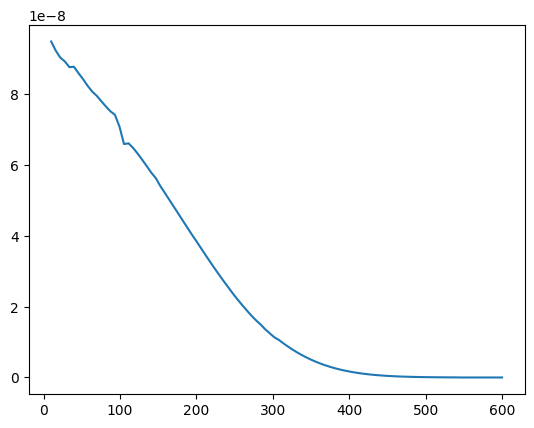

NameError: name 'calc_eta' is not defined

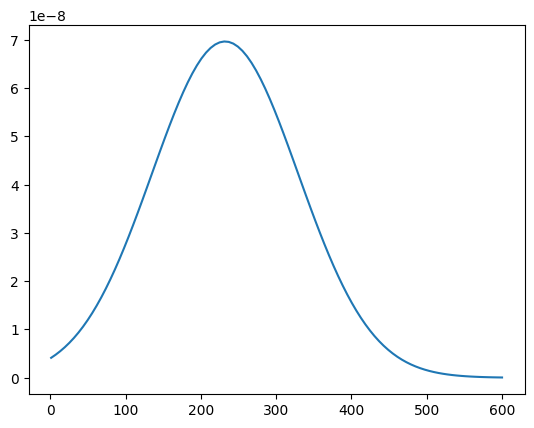

In [8]:
#calculate the minimum velocity for a given recoil energy
E_r =5e-6 #GeV
v_min = c*np.sqrt((m_N*E_r)/(2*mu_dm_N**2)) #km/s
print("velocity = ",v_min)
rho_dm = 0.3 #GeV/c^2/cm^3
v_esc = 544 #km/s
v_earth = np.array([29.2, -0.1, 5.9]) #km/s
v_sun   = np.array([11.1, 12.2, 7.3]) #km/s
v_0 = np.array([0, 238, 0]) #km/s 

v_lab = np.linspace(1, 600, 100)
speeds = []
v0 = 220.0
vesc = 544.0

z = vesc / v0
N = erf(z) - 2/np.sqrt(np.pi) * z * np.exp(-z**2)
def f_speed_earth(v, vE=232.0):
    """
    Earth-frame WIMP speed distribution f(v).
    """
    v = np.asarray(v)
    f = np.zeros_like(v)

    prefactor = 1.0 / (N * vE)

    vmin = np.abs(v - vE)
    vmax = np.minimum(v + vE, vesc)

    mask = vmin < vesc

    term = (
        np.exp(-vmin[mask]**2 / v0**2)
        - np.exp(-vmax[mask]**2 / v0**2)
    )

    f[mask] = prefactor * v[mask] * term
    return f

v0 = 220.0
vE = 232.0
vesc = 544.0
sigma_0 = np.linalg.norm(v_0)/np.sqrt(2)
z = vesc / v0
N = erf(z) - 2/np.sqrt(np.pi) * z * np.exp(-z**2)

def velocity_distribution(v_lab):
    speed = (1/N)*(3/(2*np.pi*sigma_0**2))**(3/2)*np.e**((-3*(v_lab-vE)**2)/(2*sigma_0**2))*np.heaviside(v_esc, v_lab)/v_lab
    return speed
def calculate_eta(v_min):
    if v_min > v_esc:
        eta = [0,0]
    else:
        eta = quad(velocity_distribution, v_min, np.inf)
    return(eta)
v_mins = np.linspace(10, 600, 100)
etas = []
speeds = []

for v in v_lab: 
    speeds.append(velocity_distribution(v)*v)
for v in v_mins:
    etas.append(calculate_eta(v)[0])
plt.plot(v_mins, etas)
plt.show()
plt.plot(v_lab, speeds)
print(calc_eta(v_min))


2.55581815058207e-39
1.2956535735877319e+39 1.2516402676562675e-40
1.2803155795961269e+39 1.2516402676562675e-40
1.2650886020887327e+39 1.2516402676562675e-40
1.2499738193039903e+39 1.2516402676562675e-40
1.2349723317656583e+39 1.2516402676562675e-40
1.2200851645739939e+39 1.2516402676562675e-40
1.2053132696446061e+39 1.2516402676562675e-40
1.1906575278959743e+39 1.2516402676562675e-40
1.1761187513866082e+39 1.2516402676562675e-40
1.1616976854028018e+39 1.2516402676562675e-40
1.1473950104979356e+39 1.2516402676562675e-40
1.1332113444842532e+39 1.2516402676562675e-40
1.1191472443780314e+39 1.2516402676562675e-40
1.1052032082990473e+39 1.2516402676562675e-40
1.0913796773252296e+39 1.2516402676562675e-40
1.0776770373033736e+39 1.2516402676562675e-40
1.0640956206167797e+39 1.2516402676562675e-40
1.0506357079106608e+39 1.2516402676562675e-40
1.0372975297761629e+39 1.2516402676562675e-40
1.0240812683938069e+39 1.2516402676562675e-40
1.0109870591371758e+39 1.2516402676562675e-40
9.98014992137

/var/folders/w2/bs0tpzv54b9fx3sw1nfcz58h0000gs/T/ipykernel_4558/2639267775.py:38: RuntimeWarning: divide by zero encountered in scalar divide
  sigma_N = exclusion_limit/total_rate


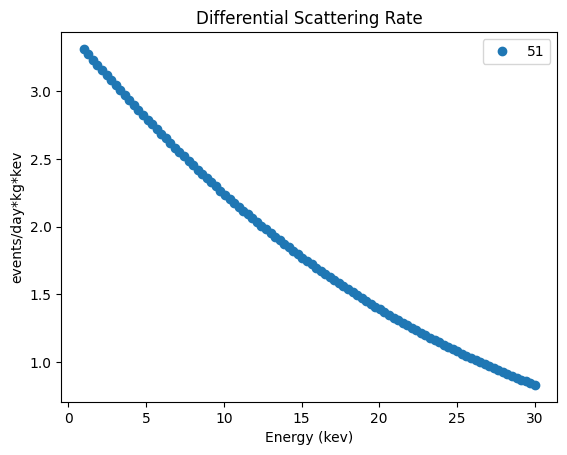

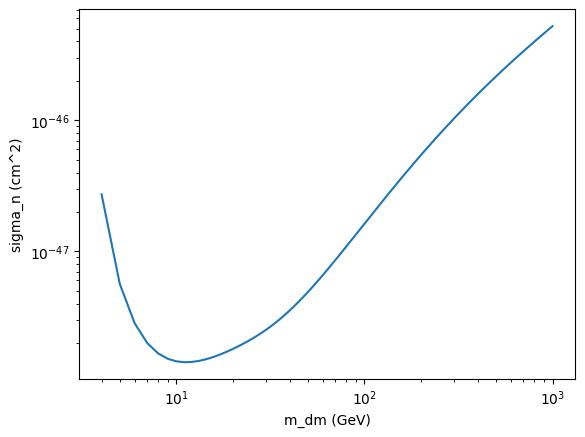

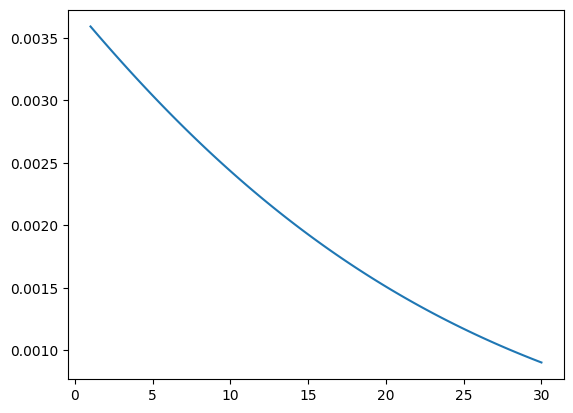

In [9]:
def differential_rates(E_r, m_dm):
    mu_dm_n = (m_dm*m_n)/(m_dm+m_n) #GeV
    mu_dm_N = (m_dm*m_N/(m_dm+m_N))
    sigma_N = sigma_n*(A**2)*(mu_dm_N/mu_dm_n)**2
    v_min = c*np.sqrt((m_N*E_r)/(2*mu_dm_N**2))
    eta = eta_SHM(v_min)
    #F = helm_form_factor(E_r)
    F = 1
    return (rho_dm/m_dm)*(1/(2*mu_dm_N**2))*F*eta, eta

recoil_energies = np.linspace(0.000001, 0.00003, 100)
bin_width = .246
rates = []
total_rate = 0
exclusion_limit = 2.3
m_dm = np.arange(1, 1000, 1)
sigma_n = 1e-46 #cm^2
sigma_N_50 = 2.55581815058207e-39 
print(sigma_N)
plot_rates = []
exclusions = []
etas = []
conversion_factor = (5.62e26*1.52e24*1.52e24*86400)/(1e6*5.07e13*5.07e13*1e5)#/bin_width #convert from these hell units to the right ones
#conversion_factor = 1e40
for m in m_dm:
    rates = []
    total_rate = 0
    for E in recoil_energies:
        rate, eta = differential_rates(E,m)
        if m == 51: etas.append(eta)
        rate2 = rate*conversion_factor*1000*365 #convert rate to events/day/kg/kev   
        if m == 51: print(rate2, sigma_N)
        if m == 51: plot_rates.append(rate2*sigma_N_50)
        rates.append(rate2)
        total_rate+=rate2*.246
    if m == 51: print("total_rate", total_rate)
    #print(m, total_rate)
    sigma_N = exclusion_limit/total_rate
    sigma_n = sigma_N/(A**2)/(mu_dm_N/mu_dm_n)**2
    exclusions.append(sigma_n)
    if m == 51:plt.plot(recoil_energies*1e6,  plot_rates, 'o', label = m)
    plt.title("Differential Scattering Rate")
    plt.ylabel("events/day*kg*kev")
    plt.xlabel("Energy (kev)")
plt.legend()
plt.show()
plt.loglog(m_dm, exclusions)
plt.ylabel("sigma_n (cm^2)")
plt.xlabel("m_dm (GeV)")
plt.show()
plt.plot(recoil_energies*1e6, etas)
plt.show()
exlusion_limit = 2.3


In [10]:
(5.62e26*1.52e24*1.52e24*86400)/(1e6*5.07e13*5.07e13)

4.3643675221455824e+46

# Electron Scattering


In [11]:
sec2year = 60*60*24*365.25 # sec/year
c_light = 299792458 # m / s
ccms = c_light*1e2
hbar    = 6.582119569e-16 # eV * s
alpha = 1/137 #fine structure constant
me_eV = .511e6 # mass of electron in eV
evtoj = 1.60218e-19 # J / eV
amu_nu = 9.314e8 # eV 
amu2kg = 1.660538782e-27 # amu to kg
alpha = 1/137.
dQ = .02*alpha*me_eV #eV
dE = 0.1 # eV
wk = 2/137
v0 = 2.2e7
vesc = 5.44e7
vE = 2.32e7
vparams = [220e5,232e5,544e5]
mu_xe = (m_dm*me_eV/(m_dm+me_eV)) #reduced mass eV
rho_dm = 0.4e9 #ev/cm^3

In [71]:
def FDM(q_eV, n=0):
    # n = 0; FDM = 1, heavy mediator
    # n = 1; FDM = 1/q, electric dipole
    # n = 2; FDM = 1/q^2, light mediator
    
    return (alpha*me_eV/q_eV)**n

def mu_Xe(mX):
    return (mX*me_eV/(mX+me_eV))

def dRdE(EE, mX):
    #print(EE)
    if EE < materials['Si'][2]:
        print("not above threshold")
        return 0
    else:
        qunit = dQ
        Eunit = dE
        Mcell = materials['Si'][0]
        Eprefactor = materials['Si'][1]
        Ei = int(np.floor(EE*10)) # eV
        prefactor = ccms**2*sec2year*rho_dm/mX*1/Mcell*alpha*me_eV**2 / mu_xe(mX)**2
        
        #prefactor = ccms**2*sec2year*rho_dm/mX*1/Mcell*3.6e-37*alpha#*me_eV**2 / mu_xe(mX)**2

        #print(prefactor)
        array_ = np.zeros(nq)
        
        for qi in range(1, nq+1):
            q = qi*qunit
            vmin = EE/q + q/(2*mX)*ccms #cm/s
            if vmin > (vesc+vE)*1.1: # rough estimate for kinematicaly allowed regions
                array_[qi-1] = 0
            else:
                eta = etaSHM(vmin, vparams)
                array_[qi-1] = Eprefactor*(1/q)*eta*FDM(q)**2*materials['Si'][4][qi-1, Ei-1]
                    
        return prefactor*np.sum(array_, axis=0) # [(kg-year)^-1]
                

not above threshold


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (10,) + inhomogeneous part.

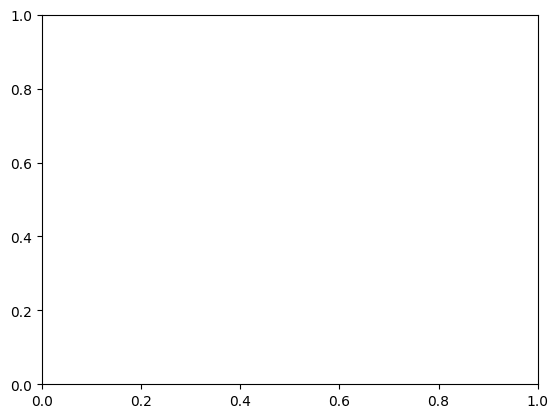

In [35]:
## import QEdark data
nq = 900
nE = 500

#get the form factors from QEDark lookup table
fcrys = {'Si': np.transpose(np.resize(np.loadtxt('Si_f2.txt',skiprows=1),(nE,nq)))}
EE = 5 #eV
mX = 1e7 #10 Mev in eV
sigma_e = 1e-37

materials = {'Si': [2*28.0855*amu2kg, 2.0, 1.2, 3.8,wk/4*fcrys['Si']]}
#print(materials['Si'][0])
#print(materials['Si'][1])
#print(dRdE(EE, mX))
rates = []
electron_energies = np.linspace(0, 40, 10)
for e in electron_energies:
    rate = dRdE(e, mX)
    rates.append(rate*sigma_e)
plt.plot(electron_energies, rates, 'o')

In [31]:
def dRdE(mX, Ee, FDMn, halo, params):
    """
    differential scattering rate for sigma_e = 1 cm^2
    at a fixed electron energy Ee
    given a DM mass, FDM, halo model
    returns dR/dE [events/kg/year]
    """
    n = FDMn
    if Ee < materials['Si'][2]: # check if less than Egap
        return 0
    else:
        qunit = dQ
        Eunit = dE
        Mcell = materials['Si'][0]
        Eprefactor = materials['Si'][1]
        Ei = int(np.floor(Ee*10)) # eV
        prefactor = ccms**2*sec2year*rho_dm/mX*1/Mcell*alpha*me_eV**2 / mu_Xe(mX)**2
        array_ = np.zeros(nq)
        for qi in range(1,nq+1):
            q = qi*qunit
            vmin = (q/(2*mX)+Ee/q)*ccms
            if vmin > (vesc+vE)*1.1: # rough estimate for kinematicaly allowed regions
                array_[qi-1] = 0
            else:
                eta = etaSHM(vmin,params) # (cm/s)^-1 
                """
                define array
                """
                array_[qi-1] = Eprefactor*(1/q)*eta*FDM(q,n)**2*materials['Si'][4][qi-1, Ei-1]
        return prefactor*np.sum(array_, axis=0) # [(kg-year)^-1]

def dRdne(mX, ne, FDMn, halo, params):
    """
    calculates rate for sigmae = 1 cm^2 in the ne bin, 
    assuming fiducial values for binsize 
    Si: 3.8 eV, Ge: 2.9 eV
    return dRdne [events/kg/year]
    """
    Ebin = materials['Si'][3]
    ## check if ne is defined
    if ne*Ebin > dE*nE:
        print('$n_e$ is out of range, pick a smaller value')
        return 0
    elif ne == 0:
        print('$n_e$ must be > 0')
        return 0
    else:    
        tmpEbin = int(np.floor(Ebin/dE))+1
        tmpdRdE = np.zeros(tmpEbin)

        for i in range(tmpEbin):
            ## add up in bins of [1.2,4.9],[5,8.7],...
            #print(dRdE(mX, ne*Ebin+dE*i+materials['Si'][2], FDMn, halo, params))
            tmpdRdE[i] = dRdE(mX, (ne-1)*Ebin+dE*i+materials['Si'][2], FDMn, halo, params)
            print((ne-1)*Ebin+dE*i+materials['Si'][2], tmpdRdE[i])
            #dRdE(mX, (ne-1)*Ebin+dE*i+materials['Si'][2], FDMn, halo, params)
        dRdne = np.sum(tmpdRdE, axis = 0)

        return dRdne


def dRdnearray(mX, Ebin, FDMn, halo, params):
    """
    calculates rate for sigmae = 1 cm^2, binned in Ebin, 
    return binlist [eV], dRdne [events/kg/year/Ebin]
    """    
    numbins = int(np.floor(nE*dE/Ebin))# calculate number of bins of size Ebin
    binlist = [materials['Si'][2]+ii*Ebin for ii in range(numbins)]
    tmpEbin = int(np.floor(Ebin/dE))
    tmpdRdE = np.zeros(tmpEbin)
    array_ = np.zeros(numbins)

    for ne in range(numbins-1):
        for i in range(tmpEbin):
            tmpdRdE[i] = dRdE(mX, ne*Ebin+dE*i+materials['Si'][2], FDMn, halo, params)
        array_[ne] = np.sum(tmpdRdE, axis = 0)
        
    return binlist, array_

def sigmae(mXlist, nevents, exposure, ne, FDMn, halo, params):
    """
    cross-section assuming nevents (3 for bkgdfree),
    exposure is in kg-years,
    takes in array of mX in MeV
    returns mX [MeV], sigma_e [cm^2]
    """
#    nevents = 3 # for bkgd free experiment
    sigmae = np.zeros(len(mXlist))
    for iimX in range(len(mXlist)):
        mX = mXlist[iimX]*1e6
        if dRdne(mX, ne, FDMn, halo, params) == 0:
            sigmae[iimX] = np.nan
        else:
            sigmae[iimX] = nevents/(dRdne(mX, ne, FDMn, halo, params)*exposure)
    return mXlist, sigmae

In [100]:
%%time
"""
calculate the rate for fixed number of electrons (ne)
"""
mX = 1e7 # 10 MeV
ne = 1
nFDM = 0
elem = 'Si'
vhalo = 'shm'
vparams = [220e5,232e5,544e5] # cm/s
sigmae=1e-37 # cm2

sigmae*dRdne(mX,ne,nFDM,vhalo,vparams)

3.8
1.2 1.093569891990895e+39
1.3 4.050544185194935e+39
1.4 0.0
1.5 0.0
1.6 1.951456136685262e+39
1.7 5.531227881755674e+39
1.8 0.0
1.9 2.0855141359679494e+40
2.0 4.902194334620317e+39
2.1 1.6278843598018858e+40
2.2 9.36436104405514e+39
2.3 8.454745731361744e+39
2.4000000000000004 2.440016960900518e+40
2.5 4.029275120241498e+39
2.6 1.1143049259519655e+40
2.7 2.0653831995482384e+40
2.8 1.7705857721633312e+40
2.9000000000000004 2.54711226469041e+40
3.0 2.53369794003953e+40
3.1 1.482436305632532e+40
3.2 3.3459183157886266e+40
3.3 3.5456351906812e+40
3.4000000000000004 2.82220787742358e+40
3.5 6.971752701876962e+39
3.6000000000000005 1.7088879779825812e+40
3.7 2.627990581702442e+40
3.8 3.3032092628855845e+40
3.9000000000000004 3.4630194989651716e+40
4.0 3.1183061181620374e+40
4.1000000000000005 3.7557198209457644e+40
4.2 3.606034717107632e+40
4.3 4.2218598554355293e+40
4.4 1.383056273952339e+40
4.5 4.442099860417011e+40
4.6000000000000005 2.6494947997815733e+40
4.7 3.395061433011345e+40
4.

75276.69035540443

3.999968689090496

In [101]:
"""
calculate the rate vs ne for specified bin size
n.b. sigmae = 1
dRdneSHMfidarray is [Ee, dRdnearray]
"""
mX = 1e7 # 10 MeV
ne = 1
nFDM = 0
elem = 'Si'
binsize = 3.8 # eV
vhalo = 'shm'
vparams = [220e5,232e5,544e5] # cm/s

dRdneSHMfidarray=dRdnearray(mX,binsize,nFDM,vhalo,vparams)

In [102]:
# print out Ee values
print('Ee values', dRdneSHMfidarray[0])
# print out Rate values
print('rate values: ',dRdneSHMfidarray[1])

Ee values [1.2, 5.0, 8.799999999999999, 12.599999999999998, 16.4, 20.2, 23.999999999999996, 27.799999999999997, 31.599999999999998, 35.4, 39.2, 43.0, 46.8]
rate values:  [7.19676414e+41 8.23344228e+41 1.47866615e+41 2.28231408e+40
 2.70902741e+39 3.59087636e+38 3.10451452e+37 1.55203833e+36
 5.53868701e+33 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00]


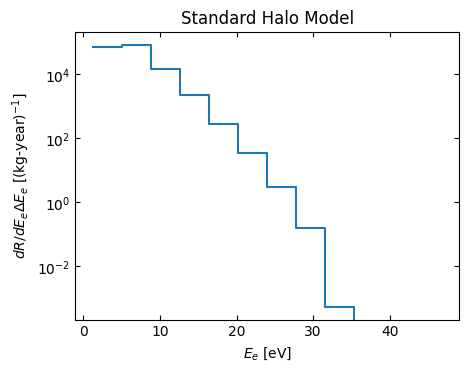

In [103]:
fig = plt.figure()
## definitions for the axes
left, width = 0.1, 0.6
bottom, height = 0.9, 0.6
sigmae=1e-37 # cm2

"""
create rate plot
"""
ff = interp1d(dRdneSHMfidarray[0],sigmae*dRdneSHMfidarray[1])
ax1 = fig.add_axes([left, bottom, width, height])
ax1.tick_params(direction='in',top=True, right=True)
ax1.step(dRdneSHMfidarray[0],sigmae*dRdneSHMfidarray[1],where='post')
#shmfid, = ax1.plot(dRdneSHMfidarray[0],sigmae*dRdneSHMfidarray[1],'o', color='black',label = 'SHM fiducial')
ax1.set_ylabel(r'$dR/dE_e\Delta E_e$ [(kg-year)$^{-1}$]')
#ax2.set_ylabel('rel. diff.')
ax1.set_title('Standard Halo Model')
ax1.set_yscale('log')
plt.xlabel(r'$E_e$ [eV]')

#plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=1.0)
plt.show()

In [32]:
"""
define parameters
"""
vhalo = 'shm'
elem = 'Si'
FDMn = 0 # FDM=1
nevents = 3 # for background-free 
exposure = 1 # kg-year
mXlist = np.logspace(-1,3,30) # DM mass from 0.1 MeV to 1 GeV, 30 points in log-space
## SHM velocity parameters in cm/s [v0,vE,vesc]
shmfidparams = [220e5,232e5,544e5]
## ne = 1, 2 electrons
sigmaSHMfidne1 = sigmae(mXlist, nevents,exposure,1,FDMn,vhalo,shmfidparams)
#sigmaSHMfidne2 = sigmae(mXlist, nevents,exposure,2,FDMn,vhalo,shmfidparams)

## save files to save time later
np.savetxt('/sigmaSHMfidne1.txt', sigmaSHMfidne1) 
#np.savetxt('/sigmaSHMfidne2.txt', sigmaSHMfidne2) 

NameError: name 'materials' is not defined

3.6000000000000005 1.9837287899076678e+40
3.7 3.0036540098067552e+40
3.8 3.7495842342881505e+40
3.9000000000000004 3.91214245767331e+40
4.0 3.4578395481936874e+40
4.1000000000000005 4.162109298094566e+40
4.2 3.9513383222144493e+40
4.3 4.547490161970281e+40
4.4 1.4789844505306789e+40
4.5 4.655970134378012e+40
4.6000000000000005 2.7728277935692873e+40
4.7 3.529189614636492e+40
4.8 2.311521939287199e+40
4.9 3.3435856300628823e+40
3.8
1.2 1.5364085269986926e+39
1.3 5.637418581838726e+39
1.4 0.0
1.5 0.0
1.6 2.6568735369984747e+39
1.7 7.559843907126855e+39
1.8 0.0
1.9 2.800437126437953e+40
2.0 6.539296301970964e+39
2.1 2.1516826254118398e+40
2.2 1.225671354726726e+40
2.3 1.0965402802431151e+40
2.4000000000000004 3.1540167898550816e+40
2.5 5.1339395964202584e+39
2.6 1.4063365094195551e+40
2.7 2.577474805693456e+40
2.8 2.225268317766152e+40
2.9000000000000004 3.123063743211488e+40
3.0 3.1245064360210245e+40
3.1 1.8062172745173542e+40
3.2 3.9867021531955507e+40
3.3 4.2388306202900144e+40
3.4000

2.7 1.0964235957342973e+40
2.8 9.404738726278408e+39
2.9000000000000004 1.371413603041124e+40
3.0 1.3652840728957142e+40
3.1 8.056855260999487e+39
3.2 1.8410715102605813e+40
3.3 1.9550499244211789e+40
3.4000000000000004 1.5745016594203893e+40
3.5 3.919647804826384e+39
3.6000000000000005 9.636739605924237e+39
3.7 1.4971502611827728e+40
3.8 1.8931841921696126e+40
3.9000000000000004 1.996826500800151e+40
4.0 1.818264923696271e+40
4.1000000000000005 2.1985389010731963e+40
4.2 2.1284089520236013e+40
4.3 2.518357080977645e+40
4.4 8.304369067201528e+39
4.5 2.7003326775158663e+40
4.6000000000000005 1.6170750489869762e+40
4.7 2.0855573970072029e+40
4.8 1.4184809504394082e+40
4.9 2.0722876880578782e+40
3.8
1.2 5.287792910220605e+38
1.3 1.9719340368136127e+39
1.4 0.0
1.5 0.0
1.6 9.668358408616981e+38
1.7 2.7425772600148006e+39
1.8 0.0
1.9 1.0478628454795868e+40
2.0 2.4770187511901002e+39
2.1 8.281387741472865e+39
2.2 4.7990543033216803e+39
2.3 4.362805008238573e+39
2.4000000000000004 1.2643985189

1.7 7.940532197577158e+38
1.8 0.0
1.9 3.054501940764487e+39
2.0 7.243351795093373e+38
2.1 2.4300881273957017e+39
2.2 1.4134681934924793e+39
2.3 1.2894615116510359e+39
2.4000000000000004 3.748469056755393e+39
2.5 6.274126336943151e+38
2.6 1.7540922532470496e+39
2.7 3.287479717031283e+39
2.8 2.828545902207035e+39
2.9000000000000004 4.14297322063942e+39
3.0 4.1365243664485835e+39
3.1 2.4510534450524305e+39
3.2 5.62454563775829e+39
3.3 5.992568098992708e+39
3.4000000000000004 4.8465673257505673e+39
3.5 1.2109708177081067e+39
3.6000000000000005 2.9884363904465763e+39
3.7 4.662937684792363e+39
3.8 5.91798624428345e+39
3.9000000000000004 6.267926708975394e+39
4.0 5.731521719374097e+39
4.1000000000000005 6.957030014140878e+39
4.2 6.762300828065499e+39
4.3 8.034279809245419e+39
4.4 2.66014454787863e+39
4.5 8.689690775328817e+39
4.6000000000000005 5.2229283585079676e+39
4.7 6.763518624102526e+39
4.8 4.6219010664759286e+39
4.9 6.778563414559582e+39
3.8
1.2 1.5080803139527409e+38
1.3 5.64288989690

4.6000000000000005 2.0748440364863e+39
4.7 2.6895400600928494e+39
4.8 1.839317441676298e+39
4.9 2.700283408793787e+39
3.8
1.2 4.2390659749971587e+37
1.3 1.5875304799095185e+38
1.4 0.0
1.5 0.0
1.6 7.877744801241299e+37
1.7 2.2415432663261725e+38
1.8 0.0
1.9 8.637894498331533e+38
2.0 2.0501373389675546e+38
2.1 6.884321459256249e+38
2.2 4.008131002799785e+38
2.3 3.6597887322982265e+38
2.4000000000000004 1.0648925817301727e+39
2.5 1.7841059475829163e+38
2.6 4.992661952177905e+38
2.7 9.365576774801335e+38
2.8 8.067779977101377e+38
2.9000000000000004 1.1826294973010257e+39
3.0 1.1821144683017212e+39
3.1 7.011660790402319e+38
3.2 1.6102820049962664e+39
3.3 1.7176791935014763e+39
3.4000000000000004 1.3903698256868583e+39
3.5 3.477204340647028e+38
3.6000000000000005 8.592150963108257e+38
3.7 1.3419964526290586e+39
3.8 1.704969978835174e+39
3.9000000000000004 1.808008082881748e+39
4.0 1.6547351499138288e+39
4.1000000000000005 2.0111148380937062e+39
4.2 1.956815555450713e+39
4.3 2.326950531615696

3.8 6.614673084575045e+38
3.9000000000000004 7.016518985638194e+38
4.0 6.422930768606113e+38
4.1000000000000005 7.808718336622498e+38
4.2 7.599688178846267e+38
4.3 9.038948781122267e+38
4.4 2.9971403457619914e+38
4.5 9.801654541039341e+38
4.6000000000000005 5.9000569617967585e+38
4.7 7.651488212049074e+38
4.8 5.2342518230186614e+38
4.9 7.687896422951361e+38
3.8
1.2 1.1901470732465003e+37
1.3 4.45815511070419e+37
1.4 0.0
1.5 0.0
1.6 2.2138212115174156e+37
1.7 6.300849245092013e+37
1.8 0.0
1.9 2.42924768554239e+38
2.0 5.767022647944359e+37
2.1 1.9370413299058328e+38
2.2 1.12806466392906e+38
2.3 1.0302808270347427e+38
2.4000000000000004 2.9986192859057843e+38
2.5 5.025122205605674e+37
2.6 1.4066024508789802e+38
2.7 2.6392490948038742e+38
2.8 2.2743473250960273e+38
2.9000000000000004 3.334522978354493e+38
3.0 3.33419727286794e+38
3.1 1.9782141052350167e+38
3.2 4.54400623016542e+38
3.3 4.848773237168088e+38
3.4000000000000004 3.925653324986499e+38
3.5 9.820206085528732e+37
3.600000000000000

OSError: [Errno 30] Read-only file system: '/sigmaSHMfidne1.txt'

(1e-42, 1e-36)

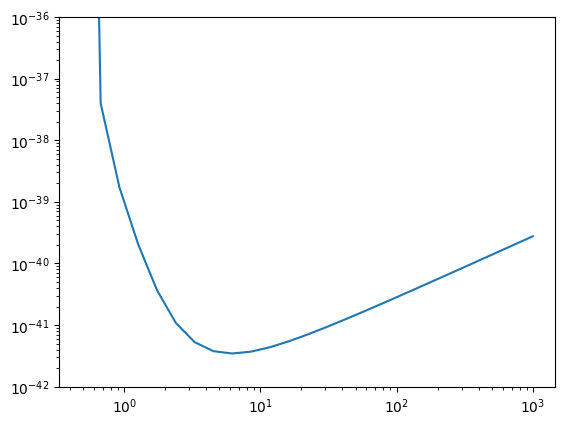

In [109]:
plt.loglog(sigmaSHMfidne1[0], sigmaSHMfidne1[1])
plt.ylim(1.0e-42, 1.0e-36)
#plot sigma_bar

In [24]:
import os
import math
import numpy as np
import scipy.special as spf
import scipy.interpolate as interp
import time
import quaternionic as qnc 
import h5py
import sys
import matplotlib.pyplot as plt
import matplotlib.colors as clr
plt.rc('text', usetex=True)


import vsdm
from vsdm.units import *
from vsdm.utilities import *
from vsdm import McalK


diffM, diffV = vsdm.testG_lm(5, -3, printout=False)
if np.abs(diffV) < 1e-14:
    print("testing 'spherical' and WignerG: PASS")
else:
    print("testing 'spherical' and WignerG: FAIL")
    print("check the version number for 'spherical', and run testD_lm()")
print("vsdm", vsdm.__version__)

deg = np.pi/180
unisize = 3.5

from scipy import optimize

testing 'spherical' and WignerG: PASS
vsdm 0.4.4


In [25]:
### Quaternion rotation from Ben's code

def getQ(theta, phi):
    #theta, phi should be in radians
    axisphi = phi + np.pi/2 #stationary under R
    axR = theta/2 
    qr = np.cos(axR)
    qi = np.sin(axR) * np.cos(axisphi)
    qj = np.sin(axR) * np.sin(axisphi)
    qk = 0. 
    return qnc.array(qr, qi, qj, qk)

def rotateBy(qR, v):
    # rotate a vector v (or array of vectors) by rotation operator qR
    return qR * v / qR

def conicalABN(v, a, b, th):
    eq1 = v@v - 1 #I think this is doing matrix multiplication 
    eq2 = (v@a - np.cos(th))**2
    eq3 = (v@b - np.cos(th))**2 
    return eq1 + eq2 + eq3

def nhat(theta, phi):
    nx = np.sin(theta) * np.cos(phi) 
    ny = np.sin(theta) * np.sin(phi) 
    nz = np.cos(theta) 
    return np.array([nx, ny, nz])


def rotationQ(theta, phi, alpha):
    "Encodes a rotation by angle 'alpha' about the (theta,phi) unit vector."
    nx,ny,nz = nhat(theta, phi)
    axR = alpha/2 
    cosah = np.cos(alpha/2) 
    sinah = np.sin(alpha/2) 
    return qnc.array(cosah, sinah*nx, sinah*ny, sinah*nz)

def qfunc(qr, vec3d):
    return qnc.array(qr, vec3d[0], vec3d[1], vec3d[2])
def findCone(thph1, thph2, thetaN):
    assert 0 < thetaN < np.pi/2, "thetaN is defined as interior cone angle, from axis of symmetry"
    theta1, phi1 = thph1 
    theta2, phi2 = thph2 
    ax1 = np.sin(theta1)*np.cos(phi1)
    ay1 = np.sin(theta1)*np.sin(phi1)
    az1 = np.cos(theta1) 
    a1 = np.array([ax1, ay1, az1])
    ax2 = np.sin(theta2)*np.cos(phi2)
    ay2 = np.sin(theta2)*np.sin(phi2)
    az2 = np.cos(theta2) 
    a2 = np.array([ax2, ay2, az2])
    assert a1 @ a2 >= np.cos(2*thetaN), "these two (theta,phi) cannot be fit to the cone."
    
    return a1 @ a2

# Specify the position of the north pole in (theta, phi)

# Draw the conical path of the DM wind in the theta, phi plane given the cone opening angle, 2*thetaN
def makeCone(theta_north, phi_north, phase, thetaN=(42*deg), dt_h=0.2):
    """Returns the Earth velocity unit vector vE as a function of time.
    
    theta_north, phi_north: a 2d unit vector specifying the location of the north pole 
        (in the crystal coordinate frame, where theta=0 is the "b=z" direction)
    phase: shifts the "t=0" starting position of vE
    thetaN: the angle between the DM wind and the north pole (radians)
    dt_h: the time step to use, in sidereal hours (24h = 360 deg)

    returns lists of tH,theta_E,phi_E, with angles in radians and times in sidereal hours
    """
    # north pole vector:
    northvec = nhat(theta_north, phi_north)
    # Step 1: find a starting position for vE, rotating "northvec" by thetaN about any orthogonal vector.
    eps = 0.005
    # default: define the rotation axis as orthogonal to "x":
    axis_init = np.cross(northvec, np.array([1, 0, 0]))
    # if northvec is colinear with "x", use the "y" axis instead:
    if np.linalg.norm(axis_init) < eps:
        axis_init = np.cross(northvec, np.array([0, 1, 0]))
    # rotate about axis_init by angle thetaN:
    one,theta_ai,phi_ai = cart_to_sph(axis_init)
    Q_init = rotationQ(theta_ai, phi_ai, thetaN)
    qnorth = qfunc(0., northvec)
    vE_init = rotateBy(Q_init, qnorth)

    Q_phase = rotationQ(theta_north, phi_north, phase)
    vE_0 = rotateBy(Q_phase, vE_init)

    # Step 2: rotate vE_0 about the north pole
    lenT = int(24.0 / dt_h) + 1 # include 24.0h at the end
    sid_times = [j*dt_h for j in range(lenT)]
    thetaE = []
    phiE = []
    for t in sid_times: 
        alpha = t/24 * 2*np.pi # rotation angle 
        Q_t = rotationQ(theta_north, phi_north, alpha) # rotation operator 
        qE_t = rotateBy(Q_t, vE_0) # rotated vector (as quaterion) 
        vE_t = qE_t.imag # convert back to 3d vector 
        one,theta,phi = cart_to_sph(vE_t) # convert to spherical coordinate
        thetaE += [theta]
        phiE += [phi]
    return np.array(sid_times), np.array(thetaE), np.array(phiE)


def dailyMod(north, thetaN, plotpoints=100, t0_h=0.):
    theta_phi_list = makeCone(north, thetaN, plotpoints=plotpoints)
    R_list = []
    t_list = []
    dt_h = 24.0/plotpoints # time between plot points, in sidereal hours
    t = t0_h #initial time, in sidereal hours
    for theta,phi in theta_phi_list:        
        q = 1/getQ(theta, phi) 
        R_list += [q]
        t_list += [t]
        t += dt_h
    return np.array(t_list),R_list

def ix_thetaphi(theta, phi):
    return thetaphilist.index((theta, phi))


In [33]:
"""Option 2: import from HDF5"""

ellMax = 24
mXlist = [2, 3, 5, 10, 20, 30, 50, 100]

DeltaE = {}
DeltaE['s1'] = 4.24*eV
DeltaE['s2'] = 4.788*eV
DeltaE['s5'] = 5.791*eV
DeltaE['s8'] = 6.439*eV

ellMax = 24
nvMax = 511
nqMax = 1023
lmod = 2

QMAX = 24*keV # Global value for q0=qMax for wavelets
Qbasis = dict(u0=QMAX, type='wavelet', uMax=QMAX)

VMAX = 820.*km_s # Global value for v0=vMax for wavelets
Vbasis = dict(u0=VMAX, type='wavelet', uMax=VMAX)



def h5modelname(sI, dmModel, mX_MeV_float=0):
    """Define a consistent style for labeling McalI[dmModel] in this hdf5.

    returns: ('sI') + '/' + ('fdm') + '/' + ('mX_MeV')
        fdm = dmModel['fdm']
        mX_MeV = dmModel['mX']/MeV
    mX_MeV_float controls how many decimal points to include in the
        string version of mX/MeV
    """
    fdm = dmModel['fdm']
    mX_MeV = dmModel['mX'] / MeV
    if mX_MeV_float==0:
        mX_str = str(int(mX_MeV))
    elif mX_MeV_float==1:
        mX_str = '{:.1f}'.format(mX_MeV)
    elif mX_MeV_float==2:
        mX_str = '{:.12}'.format(mX_MeV)
    elif mX_MeV_float==3:
        mX_str = '{:.3f}'.format(mX_MeV)
    mIstr = '{}/{}/{}'.format(sI, fdm, mX_str)
    return mIstr
    
rates = {}
with h5py.File('tstilbene_mK.hdf5','r') as hdf5:
    for sI in ['s1', 's2', 's5', 's8']:
        for n in [0,2]:
            for mX in mXlist:
                dmModel = dict(mX=mX*MeV, fdm=n, mSM=mElec, DeltaE=DeltaE[sI])
                thislabel = h5modelname(sI, dmModel, mX_MeV_float=0)
                dataK = hdf5[thislabel+'/mcalK'][:]
                newK = McalK(ellMax, lmod=2)
                newK.vecK = dataK
                rates[(sI, n, mX)] = newK

In [26]:
rates[('s5', 0, 30)].vecK[0:18]

NameError: name 'rates' is not defined

In [ ]:
for mX in mXlist:
    for n in [0, 2]:
        vecK_s1 = rates[('s1', n, mX)].vecK
        vecK_tot = np.copy(vecK_s1)
        for sI in ['s2', 's5', 's8']:
            lbl = 's1' + sI
            vecK_other = rates[(sI, n, mX)].vecK
            vecK_tot += vecK_other
            newK = McalK(ellMax, lmod=2)
            newK.vecK = vecK_s1 + vecK_other
            rates[(lbl, n, mX)] = newK
        newK = McalK(ellMax, lmod=2)
        newK.vecK = vecK_tot
        rates[('tot', n, mX)] = newK

In [ ]:
mX = mXlist[0]
n = 0
print('K_000 for mX = {} MeV, n = {}:'.format(mX, n))
for lbl in ['s1', 's2', 's5', 's8','s1s2', 's1s5', 's1s8', 'tot']:
    K000 = rates[(lbl, n, mX)].vecK[0]
    print('{}:\t{}'.format(lbl, K000))

# print('testing sum:')
ix = 3
test12 = rates[('s1', n, mX)].vecK[ix] + rates[('s2', n, mX)].vecK[ix] - rates[('s1s2', n, mX)].vecK[ix] 
print('s1 + s2 - s1s2 = {}'.format(test12))

In [34]:
data_dir = os.getcwd() + '/data/'
np.save('thetas.npy', thetas)
np.save('phis.npy', phis)

### This function only needs to be run once for each (n,mX) model.
"""Calculate WignerG matrix"""
rotationlist = []
rotationarray = []
thetaphilist = []

for theta in range(0, 181, 2):
    rrow = []
    for phi in range(0, 361, 2):
        # for WignerG, want to apply the inverse of getQ.
        # getQ applied to vE moves vE from the z axis to the position (theta, phi). 
        # 1/getQ applied to the crystal does the same thing, 
        #     with vE -> (theta, phi) in the frame of the crystal.
        q = 1/getQ(theta * np.pi/180, phi * np.pi/180) 
        rrow += [q] 
        rotationlist += [q] 
        thetaphilist += [(theta, phi)]
    rotationarray += [rrow]

rotationarray = np.array(rotationarray)

"""Calculate the Wigner G matrix for each rotation (takes ~2 minutes)"""
wG = vsdm.WignerG(ellMax, rotations=rotationlist, lmod=2)


thetas = [theta for theta in range(0, 181, 2)]
phis = [phi for phi in range(0, 361, 2)]
thetaphi_size = (np.shape(rotationarray)[0], np.shape(rotationarray)[1])

data_dir = os.getcwd() + '/data/'
np.save('thetas.npy', thetas)
np.save('phis.npy', phis)
# Assuming the same grid of theta,phi for all DM models. 
# If not, for some reason, add an identifying modelstring to file names above. 

def writeRinterpolated(n, mX, modelstring, sI='tot'):
    """Calculates WignerG and McalK, saves R(theta, phi) to file.
    
       n = 0,2: heavy/light mediator
       mX: (integer) DM mass in MeV. Choose from list
       modelstring: saves files to data/{modelstring}_{etc}

       Assumes the mK.hdf5 file is saved to 'data/tstilbene_mK.hdf5'
    """
    
    assert (n in [0,2]), "n must be 0 or 2"
    assert (mX in mXlist), "only includes mX = 2,3,5,10,20,30,50,100"
    assert (sI in ['s1', 's2', 's5', 's8', 'tot']), "only includes s1,s2,s5,s8"

    if sI=='tot':
        sIlist = ['s1', 's2', 's5', 's8']
    else: 
        sIlist = [sI]

    """Import from HDF5"""
    rates = {}
    with h5py.File('tstilbene_mK.hdf5','r') as hdf5:
        for sI in sIlist:
            dmModel = dict(mX=mX*MeV, fdm=n, mSM=mElec, DeltaE=DeltaE[sI])
            thislabel = h5modelname(sI, dmModel, mX_MeV_float=0)
            dataK = hdf5[thislabel+'/mcalK'][:]
            newK = vsdm.McalK(ellMax, lmod=2)
            newK.vecK = dataK
            rates[sI] = newK

    """Combinations of s1, s2, s5, s8:"""
    if sI=='tot':
        vecK_s1 = rates['s1'].vecK
        vecK_tot = np.copy(vecK_s1)
        for sI in ['s2', 's5', 's8']:
            vecK_tot += vecK_other
        newK = vsdm.McalK(ellMax, lmod=2)
        newK.vecK = vecK_tot
        rates['tot'] = newK
    else:
        rates['tot'] = rates[sI]

    # Only using rates['tot'] going forwards. 


    """Rate calculation, including isotropic norm <R>:"""
    rate_R = rates['tot'].mu_R(wG).reshape(thetaphi_size) # rate, sans exposure factor 'mu0'
    rate_K000 = rates['tot'].vecK[0] # the ell=0 component of vecK is the angular average

    """Save R(theta,phi), etc to binary files:"""
    data_dir = os.getcwd() + '/data/'
    np.save(modelstring+'_rateArray.npy', rate_R)
    np.save(modelstring+'_K000.npy', np.array(rate_K000)) # convenient integer K_000
    

    

In [32]:
class simpleRate():
    def __init__(self, modelstring, sigma0_cm2= 1e-38, mass_kg=1.):
        # read data from npy:
        data_dir = os.getcwd() + '/data/'
        self.thetas = np.load('thetas.npy') # in degrees
        self.phis = np.load('phis.npy') # in degrees
        self.K000 = np.load(modelstring+'_K000.npy')
        self.rate_array = np.load(modelstring+'_rateArray.npy')

        our_rhoX = 0.4 #GeV/cm^3
        """Exposure Factor:
            exp_kgyr: total exposure time*mass. 
                To get a rate in Hz, choose exp_kgyr = (mass/kg) * (1/3.15e7) 
        """
        exp_time_yr = 1./vsdm.SECONDS_PER_YEAR # for rate in Hertz. 
        self.k0 = vsdm.g_k0(exp_kgyr=mass_kg*exp_time_yr, sigma0_cm2=sigma0_cm2, rhoX_GeVcm3=our_rhoX, 
                            mCell_g=4*(180.250), # molar mass of TSB crystal unit cell 
                            v0=Vbasis['u0'], q0=Qbasis['u0']) # global constants from mK.hdf5

        self.isoR_Hz = self.K000 * self.k0 # isotropic average rate <R> in Hz
        """Define the interpolating function R(theta, phi):"""
        data = np.array([[self.rate_array[ix, iy]
                          for iy in range(len(phis))] 
                         for ix in range(len(thetas))])
        self.rate_intp_deg = interp.RegularGridInterpolator((thetas, phis), data)  # in degrees

    def dailyModMe(self, theta_north, phi_north, phase, thetaN=(42*deg), dt_h=0.25):
        """Returns the rate as a function of time for a daily modulation analysis.
    
        rate_intp: interpolating function R(theta, phi), for theta and phi in degrees 
        theta_north, phi_north, phase: orientation of the sample
        thetaN: angle between "north" and the DM wind. Varies annually
        dt_h: time step size, in sidereal hours
    
        returns the lists tH,R(tH) 
        """
        print("thetaN", thetaN)
        t_h, thetaE, phiE = makeCone(theta_north, phi_north, phase, thetaN=thetaN, dt_h=dt_h)
        rate_Hz = self.k0*self.rate_intp_deg([[thetaE[j]/deg, phiE[j]/deg] for j in range(len(t_h))])
        return t_h, rate_Hz
        

In [ ]:
for n in [0, 2]:
    for mX in [2, 3, 5, 10, 20, 30, 50, 100]:
        modname = 'tot_n{}_mX{}'.format(n, mX)
        writeRinterpolated(n, mX, modname, sI='tot')

In [ ]:
for n in [0, 2]:
    for mX in [2, 3, 5, 10, 20, 30, 50, 100]:
        modname = 's1_n{}_mX{}'.format(n, mX)
        writeRinterpolated(n, mX, modname, sI='s1')

In [ ]:
# Example 2: Using simpleRate()

n = 2
mX = 5 # MeV
dm_model = simpleRate('s1_n{}_mX{}'.format(n, mX), sigma0_cm2 =1, mass_kg=0.02)
print('<R> = {:.5e} Hz'.format(dm_model.isoR_Hz))

theta_north = 35*deg
phi_north = 245*deg
phase = 0*deg
thetaN = 42*deg # close to the January average
t_h, Ra_Hz = dm_model.dailyModMe(theta_north, phi_north, phase, thetaN=thetaN)

theta_north = 35*deg
phi_north = 245*deg
phase = 180*deg
thetaN = 42*deg # close to the January average
t_h, Rb_Hz = dm_model.dailyModMe(theta_north, phi_north, phase, thetaN=thetaN)

In [ ]:
"""Plot R(t):"""
print(t_h)
fig = plt.figure(figsize=[2.0*unisize,unisize])
ax2 = fig.add_axes([0,0,1,0.7], xscale='l
inear', yscale='linear')
ax2.set_xlabel(r'$t$ [sid. hours]', fontsize=13, usetex=True)
ax2.set_ylabel(r'$R$ [Hz]', fontsize=13, usetex=True)
ax2.set_xlim([0,24])
# ax2.set_ylim([min_R, max_R])
ax2.set_xticks([t for t in range(0, 25, 3)])

ax2.grid(color='gray', linestyle='-', linewidth=0.5)


ax2.plot(t_h, Ra_Hz, color='red')
ax2.plot(t_h, Rb_Hz, color='black')
# mX, n label:
ax2.text(0.98, 0.96, r'$m_\chi = {}$ MeV, $n={}$'.format(mX, n), 
         horizontalalignment='right',
         verticalalignment='top', fontsize=12, 
         color='black', 
         backgroundcolor='white',
         transform=ax2.transAxes, usetex=True)


# plt.savefig('out/modRate_mX{}_n{}_eg.png'.format(mX, n), 
#             format="png", dpi=600, bbox_inches='tight')

fig.show()

In [15]:
mXlist = [2, 3, 5, 10, 20, 30, 50, 100]
exclusion_sigma_mod = []
binned_sigma = 1
time_bins = np.arange(0, 97, 1)
print(time_bins)

for m in mXlist:
    dm_model = simpleRate('tot_n{}_mX{}'.format(0, m), sigma0_cm2 =1, mass_kg=0.02)
    theta_north = 35*deg
    phi_north = 245*deg
    phase = 0*deg
    thetaN = 42*deg # close to the January average
    t_h, Ra_Hz = dm_model.dailyModMe(theta_north, phi_north, phase, thetaN=thetaN)
    rate = Ra_Hz*900
    binned_sigma = 1
    print(binned_sigma)
    for t in time_bins:
        sigma = 5.381/rate[t]
        #print(sigma)
        binned_sigma = binned_sigma+(1/sigma)
    print(1/binned_sigma)
    exclusion_sigma_mod.append(1/binned_sigma)
plt.loglog(mXlist, exclusion_sigma_mod)
plt.xlabel("Mass (MeV)")
plt.ylabel("sigma_bar")
plt.title("Basic exclusion limit for 20 g of stilbene over 1 month with 10 minute time binning")
plt.show()


[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96]


NameError: name 'simpleRate' is not defined

In [21]:
rate_all = {}
for key in rates.keys():
    rate_R = rates[key].mu_R(wG)
    rate_all[key] = rate_R
    print('{}: <R> = {}'.format(key, rate_all[key]))

('s1', 0, 2): <R> = [0.18588111]
('s1', 0, 3): <R> = [0.98330786]
('s1', 0, 5): <R> = [2.06948831]
('s1', 0, 10): <R> = [2.12484964]
('s1', 0, 20): <R> = [1.36465676]
('s1', 0, 30): <R> = [0.97059156]
('s1', 0, 50): <R> = [0.60943486]
('s1', 0, 100): <R> = [0.31419827]
('s1', 2, 2): <R> = [0.12451586]
('s1', 2, 3): <R> = [0.40289469]
('s1', 2, 5): <R> = [0.61693241]
('s1', 2, 10): <R> = [0.5263106]
('s1', 2, 20): <R> = [0.32552924]
('s1', 2, 30): <R> = [0.23113274]
('s1', 2, 50): <R> = [0.14544562]
('s1', 2, 100): <R> = [0.07524852]
('s2', 0, 2): <R> = [0.01373658]
('s2', 0, 3): <R> = [0.08105402]
('s2', 0, 5): <R> = [0.19756679]
('s2', 0, 10): <R> = [0.22485783]
('s2', 0, 20): <R> = [0.15026001]
('s2', 0, 30): <R> = [0.10804824]
('s2', 0, 50): <R> = [0.06838479]
('s2', 0, 100): <R> = [0.0354504]
('s2', 2, 2): <R> = [0.01174082]
('s2', 2, 3): <R> = [0.04783338]
('s2', 2, 5): <R> = [0.08094474]
('s2', 2, 10): <R> = [0.07429762]
('s2', 2, 20): <R> = [0.04786791]
('s2', 2, 30): <R> = [0.0

rates in Hz:
('s1', 0, 2): [6.96448857e+33]
('s1', 0, 3): [3.68420245e+34]
('s1', 0, 5): [7.75384208e+34]
('s1', 0, 10): [7.96126676e+34]
('s1', 0, 20): [5.11301898e+34]
('s1', 0, 30): [3.6365577e+34]
('s1', 0, 50): [2.28339616e+34]
('s1', 0, 100): [1.17722035e+34]
('s1', 2, 2): [4.66529011e+33]
('s1', 2, 3): [1.50954311e+34]
('s1', 2, 5): [2.31148754e+34]
('s1', 2, 10): [1.97195088e+34]
('s1', 2, 20): [1.2196746e+34]
('s1', 2, 30): [8.6599511e+33]
('s1', 2, 50): [5.44947451e+33]
('s1', 2, 100): [2.81936917e+33]
('s2', 0, 2): [5.14674523e+32]
('s2', 0, 3): [3.03688623e+33]
('s2', 0, 5): [7.4023212e+33]
('s2', 0, 10): [8.42484648e+33]
('s2', 0, 20): [5.62985729e+33]
('s2', 0, 30): [4.04829067e+33]
('s2', 0, 50): [2.5622029e+33]
('s2', 0, 100): [1.32823557e+33]
('s2', 2, 2): [4.39898465e+32]
('s2', 2, 3): [1.79219392e+33]
('s2', 2, 5): [3.03279185e+33]
('s2', 2, 10): [2.78374138e+33]
('s2', 2, 20): [1.79348768e+33]
('s2', 2, 30): [1.29200611e+33]
('s2', 2, 50): [8.22787681e+32]
('s2', 2,

rates in Hz:
('s1', 0, 2): [1.04467329e+34]
('s1', 0, 3): [5.52630367e+34]
('s1', 0, 5): [1.16307631e+35]
('s1', 0, 10): [1.19419001e+35]
('s1', 0, 20): [7.66952847e+34]
('s1', 0, 30): [5.45483655e+34]
('s1', 0, 50): [3.42509424e+34]
('s1', 0, 100): [1.76583053e+34]
('s1', 2, 2): [6.99793517e+33]
('s1', 2, 3): [2.26431466e+34]
('s1', 2, 5): [3.46723131e+34]
('s1', 2, 10): [2.95792632e+34]
('s1', 2, 20): [1.82951191e+34]
('s1', 2, 30): [1.29899266e+34]
('s1', 2, 50): [8.17421177e+33]
('s1', 2, 100): [4.22905376e+33]
('s2', 0, 2): [7.72011785e+32]
('s2', 0, 3): [4.55532934e+33]
('s2', 0, 5): [1.11034818e+34]
('s2', 0, 10): [1.26372697e+34]
('s2', 0, 20): [8.44478594e+33]
('s2', 0, 30): [6.07243601e+33]
('s2', 0, 50): [3.84330436e+33]
('s2', 0, 100): [1.99235336e+33]
('s2', 2, 2): [6.59847697e+32]
('s2', 2, 3): [2.68829088e+33]
('s2', 2, 5): [4.54918778e+33]
('s2', 2, 10): [4.17561207e+33]
('s2', 2, 20): [2.69023152e+33]
('s2', 2, 30): [1.93800917e+33]
('s2', 2, 50): [1.23418152e+33]
('s2

python(12365) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(12370) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(12373) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(12377) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(12387) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(12395) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(12400) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


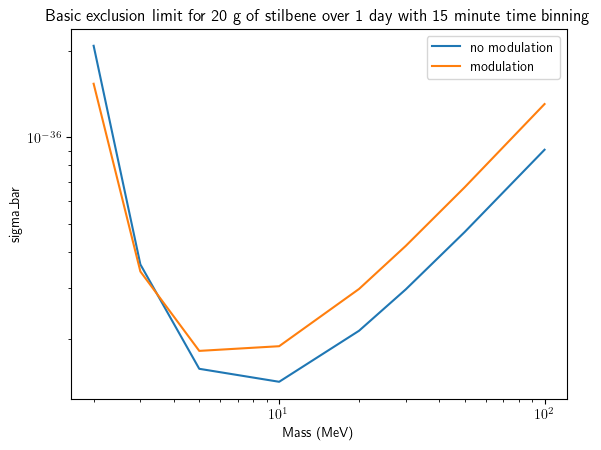

In [155]:
"""exposure factor for 20 g of trans-stilbene, for 10 minute"""
k0 = vsdm.g_k0(exp_kgyr=0.02/35040, mCell_g=721.0, 
               sigma0_cm2=1, rhoX_GeVcm3=0.4, 
               v0=Vbasis['u0'], q0=Qbasis['u0'])

"""angular averages <R> for each model:"""
print('rates in Hz:')
for key in rate_all.keys():
    K000 = rate_all[key]
    print('{}: {}'.format(key, K000*k0))

mXlist = [2, 3, 5, 10, 20, 30, 50, 100]
exclusion_sigma = []
binned_sigma = 1
time_bins = np.arange(0, 97, 1)
for m in mXlist:
    rate = rate_all[('tot', 0, m)]*k0
    binned_sigma = 1
    print(binned_sigma)
    for t in time_bins:
        sigma = 2.3/rate
        #print(sigma)
        binned_sigma = binned_sigma+(1/sigma)
    print(1/binned_sigma)
    exclusion_sigma.append(1/binned_sigma)
plt.loglog(mXlist, exclusion_sigma, label="no modulation")
plt.loglog(mXlist, exclusion_sigma_mod, label = "modulation")
plt.xlabel("Mass (MeV)")
plt.ylabel("sigma_bar")
plt.title("Basic exclusion limit for 20 g of stilbene over 1 day with 15 minute time binning")
plt.legend()
plt.show()

rates in Hz:
('s1', 0, 2): [3.050446e+37]
('s1', 0, 3): [1.61368067e+38]
('s1', 0, 5): [3.39618283e+38]
('s1', 0, 10): [3.48703484e+38]
('s1', 0, 20): [2.23950231e+38]
('s1', 0, 30): [1.59281227e+38]
('s1', 0, 50): [1.00012752e+38]
('s1', 0, 100): [5.15622513e+37]
('s1', 2, 2): [2.04339707e+37]
('s1', 2, 3): [6.6117988e+37]
('s1', 2, 5): [1.01243154e+38]
('s1', 2, 10): [8.63714484e+37]
('s1', 2, 20): [5.34217476e+37]
('s1', 2, 30): [3.79305858e+37]
('s1', 2, 50): [2.38686984e+37]
('s1', 2, 100): [1.2348837e+37]
('s2', 0, 2): [2.25427441e+36]
('s2', 0, 3): [1.33015617e+37]
('s2', 0, 5): [3.24221668e+37]
('s2', 0, 10): [3.69008276e+37]
('s2', 0, 20): [2.46587749e+37]
('s2', 0, 30): [1.77315131e+37]
('s2', 0, 50): [1.12224487e+37]
('s2', 0, 100): [5.8176718e+36]
('s2', 2, 2): [1.92675528e+36]
('s2', 2, 3): [7.84980936e+36]
('s2', 2, 5): [1.32836283e+37]
('s2', 2, 10): [1.21927872e+37]
('s2', 2, 20): [7.85547605e+36]
('s2', 2, 30): [5.65898678e+36]
('s2', 2, 50): [3.60381004e+36]
('s2', 2,

python(61514) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(61517) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


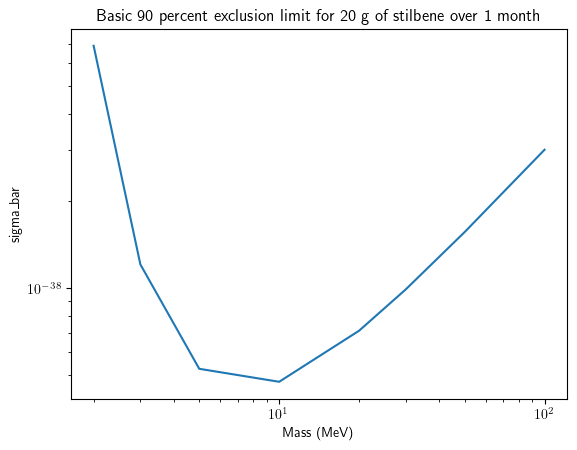

In [102]:
"""exposure factor for 20 g of trans-stilbene, for 10 minutes with time binning"""
k0 = vsdm.g_k0(exp_kgyr=0.02/12, mCell_g=721.0, 
               sigma0_cm2=1, rhoX_GeVcm3=0.4, 
               v0=Vbasis['u0'], q0=Qbasis['u0'])

"""angular averages <R> for each model:"""
print('rates in Hz:')
for key in rate_all.keys():
    K000 = rate_all[key]
    print('{}: {}'.format(key, K000*k0))

mXlist = [2, 3, 5, 10, 20, 30, 50, 100]
exclusion_sigma = []
binned_sigma = 0
time_bins = np.arange(0, 4380, 1)
for m in mXlist:
    rate = rate_all[('tot', 0, m)]*k0
    sigma = 2.3/rate
    print(sigma)
    exclusion_sigma.append(sigma)
plt.loglog(mXlist, exclusion_sigma)
plt.xlabel("Mass (MeV)")
plt.ylabel("sigma_bar")
plt.title("Basic 90 percent exclusion limit for 20 g of stilbene over 1 month")
plt.show()

In [2]:
def poisson_upper_limit(n_obs, mu_b, cl=0.90):
    """
    Compute upper limit on signal mean mu_s at confidence level CL,
    given observed counts n_obs and expected background mu_b.
    
    Solves: P(X <= n_obs | mu_s + mu_b) = 1 - CL
    """
    alpha = 1.0 - cl  # 0.10 for 90% CL

    # If mu_s=0, check if we already exclude at this CL
    if poisson.cdf(n_obs, mu_b) <= alpha:
        return 0.0  # background alone already excludes

    def equation(mu_s):
        return poisson.cdf(n_obs, mu_s + mu_b) - alpha

    # Bracket the root: upper bound where CDF is well below alpha
    mu_s_upper = max(50, n_obs * 10)
    while poisson.cdf(n_obs, mu_s_upper + mu_b) > alpha:
        mu_s_upper *= 2

    mu_s_limit = brentq(equation, 0, mu_s_upper, xtol=1e-6)
    return mu_s_limit

In [5]:
# --- Your experiment parameters ---
exposure_time = 1.0   # seconds (set your actual exposure)
mu_b = 11.2  # expected background events

# Sensitivity limit: assume you observe n_obs = 0 (best case / projected)
# Or use n_obs = round(mu_b) for the "median expected" limit
n_obs = round(mu_b)

mu_s_limit = poisson_upper_limit(n_obs, mu_b, cl=0.90)

print(f"Expected background: {mu_b:.4f} events")
print(f"Observed events: {n_obs}")
print(f"90% CL upper limit on signal: {mu_s_limit:.4f} events")

Expected background: 11.2000 events
Observed events: 11
90% CL upper limit on signal: 5.3981 events


In [14]:
def binned_poisson_limit(time_bins, signal_rate_func, R_b, sigma_ref,
                          n_obs=None, cl=0.90):
    """
    Find 90% CL upper limit on cross section with time-varying signal rate.
    
    Parameters
    ----------
    time_bins   : array of (t_start, t_end) pairs in seconds
    signal_rate_func : function(t, sigma) -> rate in events/sec at time t
                       for cross section sigma
    R_b         : background rate in events/sec (constant)
    sigma_ref   : reference cross section to scan around
    n_obs       : observed counts per bin (None = assume 0 observed)
    cl          : confidence level (default 0.90)
    """
    dt = np.array([t[1] - t[0] for t in time_bins])
    t_centers = np.array([0.5*(t[0] + t[1]) for t in time_bins])
    
    if n_obs is None:
        # Projected sensitivity: observe exactly background (or 0)
        n_obs = np.zeros(len(time_bins), dtype=int)
    
    def log_likelihood(sigma):
        mu_s = np.array([signal_rate_func(t, sigma) for t in t_centers]) * dt
        mu_b = R_b * dt
        mu_total = mu_s + mu_b
        # Sum of log Poisson likelihoods over bins
        log_L = np.sum(-mu_total + n_obs * np.log(mu_total + 1e-300))
        return log_L
    
    def test_statistic(sigma):
        # Profile likelihood ratio test statistic q_mu (Cowan et al.)
        # Under H0 (sigma=0), find best fit sigma_hat
        result = minimize_scalar(lambda s: -log_likelihood(s),
                                  bounds=(0, sigma_ref * 100),
                                  method='bounded')
        sigma_hat = result.x
        log_L_hat = log_likelihood(sigma_hat)
        log_L_sig = log_likelihood(sigma)
        
        q = -2 * (log_L_sig - log_L_hat)
        return max(q, 0)  # one-sided: q_mu >= 0
    
    # 90% CL corresponds to q_mu = 2.706 (chi-squared with 1 dof, one-sided)
    # For simple upper limit with n_obs=0, can also use CDF inversion
    q_threshold = 2.706  # for 90% CL one-sided

    def equation(sigma):
        return test_statistic(sigma) - q_threshold

    # Find the sigma where test statistic crosses threshold
    sigma_lo = sigma_ref * 1e-3
    sigma_hi = sigma_ref * 1e3
    sigma_limit = brentq(equation, sigma_lo, sigma_hi, xtol=1e-30)
    return sigma_limit


# --- Example: daily modulation ---
def signal_rate(t, sigma, m_dm=1.0):
    """
    Example: sinusoidally modulating signal rate.
    Replace with your actual rate calculation.
    """
    T_day = 86400.0  # seconds
    R0 = sigma * 1e40 * 1.0  # placeholder normalization
    modulation = 1.0 + 0.1 * np.sin(2 * np.pi * t / T_day)
    return R0 * modulation

# Set up time bins (e.g. 1 day of data in 1-hour bins)
T_obs = 86400.0   # 1 day in seconds
n_bins = 24
edges = np.linspace(0, T_obs, n_bins + 1)
time_bins = [(edges[i], edges[i+1]) for i in range(n_bins)]

R_b = 3.11e-2  # events/sec background

sigma_ref = 1e-40  # cm^2, your reference cross section
sigma_lim = binned_poisson_limit(time_bins, signal_rate, R_b, sigma_ref, n_obs = 0)
print(f"90% CL upper limit: sigma < {sigma_lim:.3e} cm^2")

90% CL upper limit: sigma < 1.000e-43 cm^2


1.0000000000000001e-60

1.9999999999999998e+30

5e-31